Imagine you have built a machine learning model to predict house prices. On your training data, it achieves **99% accuracy**, a stunning result. But when you deploy it to predict prices for new houses in the market, its predictions are wildly off. What went wrong? Your model did not learn the underlying patterns of house pricing; instead, it __memorized__ the specific quirks of your training set. This is __overfitting__, and it is one of the most common failure modes in machine learning. A model that performs beautifully on training data but fails on new data is worthless in production.

**Regularization** is the antidote. Rather than letting your model grow as complex as it wants, regularization penalizes complexity, forcing the model to stay simple and generalize better to new data. In this lesson, you will master three complementary techniques: __data scaling__, which is a prerequisite that ensures fair regularization across features with different units; __ridge regression__, which shrinks coefficients toward zero but keeps them all; and __LASSO regression__, which performs automatic feature selection by shrinking some coefficients to exactly zero.

By the end, you will know when to use each technique and how to tune them for your specific goal, whether that is __prediction accuracy__, __model interpretability__, or __feature reduction__.

Suppose your regression model has two predictors: age in years and annual income in dollars. When you add an __L2 penalty__ to shrink coefficients, the penalty hits the income coefficient far harder than the age coefficient, not because income matters less, but simply because its units are larger. That distortion breaks regularization before it even starts. In this notebook, you will see exactly how __data scaling__ removes that distortion and why it belongs at the top of every regularization workflow.

### __Introducing scaling__

Scaling data is crucial when preparing it for machine learning models, especially for those that involve regularisation. Regularisation techniques, such as L1 (Lasso) and L2 (Ridge) regularisation, adjust model complexity by applying penalties to the coefficients of predictors. The magnitude of these penalties is influenced by the scale of the predictors, making scaling an essential step to ensure fairness and effectiveness in regularisation. Essentially, if the features are on different scales, the model might unfairly penalise smaller-scale features more than those on a larger scale. Therefore, to apply regularisation uniformly across all features, we must standardise their scales.

There are two common scaling techniques:

#### **Normalisation**

One way to do this is with $[0,1]$-normalisation, otherwise known as min-max normalisation: squeezing your data into the range $[0,1]$. Through normalisation, the maximum value of a variable becomes one, the minimum becomes zero, and the values in between become decimals between zero and one.

We implement this transformation by applying the following operation to each of the values of a predictor variable:

$$\hat{x}_{ij} = \frac{x_{ij}-min(x_j)}{max(x_j)-min(x_j)},$$

where $\hat{x}_{ij}$ is the value after normalisation, $x_{ij}$ is the $i^{th}$ item of $x_j$, and $min()$, $max()$ return the smallest and largest values of variable $x_j$ respectively.

Normalisation is useful because it ensures all variables share the same range: $[0,1]$. One problem with normalisation, however, is that if there are outliers, the bulk of your data will all lie in a small range, so you will lose information.

#### __Standardisation__

Z-score standardisation, or simply standardisation, on the other hand, does not suffer from this drawback as it handles outliers gracefully.

We implement Z-score standardisation by applying the following operation to each of our variables:

$$\hat{x}_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}.$$

Here, $\mu_j$ represents the mean of variable $x_j$, while $\sigma_j$ is the variable's standard deviation. As can be seen from the above formula, instead of dividing by the full range of our variable, we instead divide by a more distribution-aware measure in the standard deviation. While this doesn't completely remove the effects of outliers, it does consider them in a more conservative manner. As a trade-off to using this transformation, our variable is no longer contained within the $[0,1]$ range as it was during normalisation (in fact, it can now take on a range which includes negative values). This means that all our variables won't be bound to the exact same range (i.e. they can have slightly different influence levels on the learned regression coefficients during regularisation), but they are far closer to one another than they were before the use of standardisation.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# import scaler method from sklearn
from sklearn.preprocessing import StandardScaler

In [2]:
from styleplot import style_plot

In [3]:
#df = pd.read_csv("https://cdn.alx-ai-tools.com/marimo/v2/data/SDG_15_Life_on_Land_Dataset.csv", index_col=0)
#df.to_csv("SDG_15_Life_on_Land_Dataset.csv", index = False)

In [4]:
df = pd.read_csv("SDG_15_Life_on_Land_Dataset.csv")
df.head()

,WaterQualityIndex,ClimateChangeImpactScore,LandUseChange,InvasiveSpeciesCount,ConservationFunding,EcoTourismImpact,ForestCoverChange,SoilQualityIndex,WaterUsage,RenewableEnergyUsage,CarbonEmissionLevels,AgriculturalIntensity,HabitatConnectivity,SpeciesReintroductionEfforts,PollinatorDiversity,BiodiversityHealthIndex
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795
3,36,7.060190,7.061932,37,88,9.718453,3.425382,64,85,96,60,1.065595,4.938359,2.192657,0.145065,0.926146
4,24,8.439246,4.504786,41,88,9.118186,-1.295086,12,0,85,61,9.785784,2.114002,7.405189,0.809798,0.126345


In [5]:
import re

df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df.columns
]

In [6]:
df.head(3)

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity,biodiversity_health_index
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795


In [7]:
print(df.shape)

(1000, 16)


Our dataset contains various environmental indicators related to SDG 15, such as deforestation rates, protected area coverage, biodiversity indices, and other relevant variables. Our objective is to model an environmental outcome for  the health of biodiversity using these indicators.

The mathematical representation of our model can be described as follows:

$$Y = \beta_0 + \beta_1X_1 + \beta_2X_2 + ... + \beta_pX_p$$

In this formulation, $Y$ represents the response variable, which in our case is `BiodiversityHealthIndex`. This response variable is influenced by _p_ predictor variables ($X_1, X_2, ..., X_p$), each representing different environmental indicators relevant to SDG 15.


We can see in the data above that the variables have different scales. For example, variables such as `ConservationFunding` may involve financial values potentially reaching into high numerical ranges, whereas other variables like `ProtectedAreaCoverage` or `RenewableEnergyUsage` are expressed as percentages. So let's go ahead and implement scaling.

## Implementing scaling

Let's see how we standardise the features. Sklearn makes rescaling easy. We'll import the `StandardScaler()` object from `sklearn.preprocessing

In [9]:
# split data into predictors and response
X = df.drop('biodiversity_health_index', axis=1)
y = df['biodiversity_health_index']

In [10]:
# create scaler object
scaler = StandardScaler()

In [11]:
# create scaled version of the predictors (there is no need to scale the response)
X_scaled = scaler.fit_transform(X)

In [12]:
# convert the scaled predictor values into a DataFrame
X_standardise = pd.DataFrame(X_scaled,columns=X.columns)
X_standardise.head()

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity
0,-0.509823,0.915895,0.532798,0.967295,-0.129430,-1.297085,0.017923,0.689812,-0.641157,-1.290990,-0.930835,-1.237558,-1.131411,1.494660,-0.811078
1,-1.261473,-1.159761,0.479063,1.382383,-1.098165,1.226669,-1.649745,0.655167,0.539995,0.207271,0.470716,-0.670150,0.305779,-0.107952,0.797582
2,-1.363971,-1.409483,1.389846,0.206299,0.320340,-0.529103,-0.877370,0.759101,1.165311,-0.473757,-0.110415,1.006319,1.598836,-1.017291,-1.518029
3,-0.475658,0.746916,0.684528,0.828932,1.323673,1.653728,1.188117,0.481943,1.165311,1.535274,0.368164,-1.360736,0.001642,-0.978326,-1.249998
4,-0.885648,1.230038,-0.213905,1.105658,1.323673,1.445945,-0.439815,-1.319584,-1.787570,1.160709,0.402348,1.675792,-0.977884,0.832482,1.077254


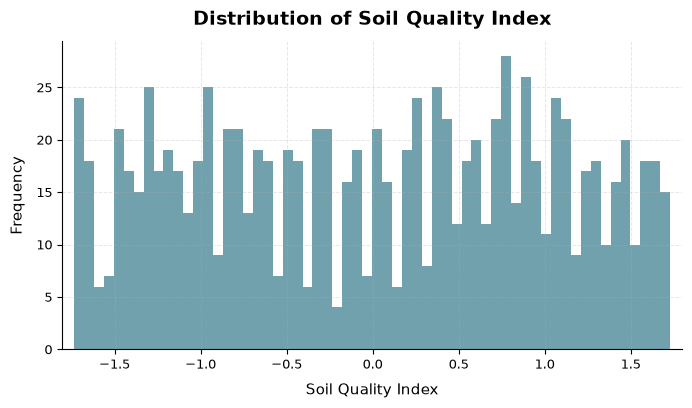

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    X_standardise["soil_quality_index"],
    bins = 60,
    alpha=0.7,
    color = "#347989"
)

style_plot(
    ax,
    title="Distribution of Soil Quality Index",
    xlabel="Soil Quality Index",
    ylabel="Frequency",
    grid=True,
)

plt.show()

Furthermore, the standard error within each variable in the data is now equal to one.

In [18]:
X_standardise.describe().loc['std']

water_quality_index               1.0005
climate_change_impact_score       1.0005
land_use_change                   1.0005
invasive_species_count            1.0005
conservation_funding              1.0005
eco_tourism_impact                1.0005
forest_cover_change               1.0005
soil_quality_index                1.0005
water_usage                       1.0005
renewable_energy_usage            1.0005
carbon_emission_levels            1.0005
agricultural_intensity            1.0005
habitat_connectivity              1.0005
species_reintroduction_efforts    1.0005
pollinator_diversity              1.0005
Name: std, dtype: float64

### __Implementing min-max normalisation__

Let's see how we normalise the features. Sklearn makes rescaling easy. We'll import the `MinMaxScaler()` object from `sklearn.preprocessing`.

In [19]:
# import scaler method from sklearn
from sklearn.preprocessing import MinMaxScaler

In [20]:
# create scaler object
min_max_scaler = MinMaxScaler()

In [21]:
# create scaled version of the predictors (there is no need to scale the response)
X_scaled_m = min_max_scaler.fit_transform(X)

In [26]:
X_standardise_df = pd.DataFrame(X_scaled_m, columns = X.columns)
X_standardise_df.head()

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity
0,0.35,0.756418,0.663048,0.78,0.46,0.119325,0.501538,0.70,0.33,0.13,0.22,0.141846,0.166341,0.931904,0.270616
1,0.13,0.162080,0.647743,0.90,0.18,0.849463,0.015804,0.69,0.67,0.57,0.63,0.304904,0.581314,0.469659,0.730607
2,0.10,0.090575,0.907161,0.56,0.59,0.341507,0.240770,0.72,0.85,0.37,0.46,0.786679,0.954671,0.207377,0.068465
3,0.36,0.708033,0.706265,0.74,0.88,0.973014,0.842375,0.64,0.85,0.96,0.60,0.106448,0.493498,0.218615,0.145108
4,0.24,0.846369,0.450364,0.82,0.88,0.912901,0.368214,0.12,0.00,0.85,0.61,0.979068,0.210670,0.740911,0.810579


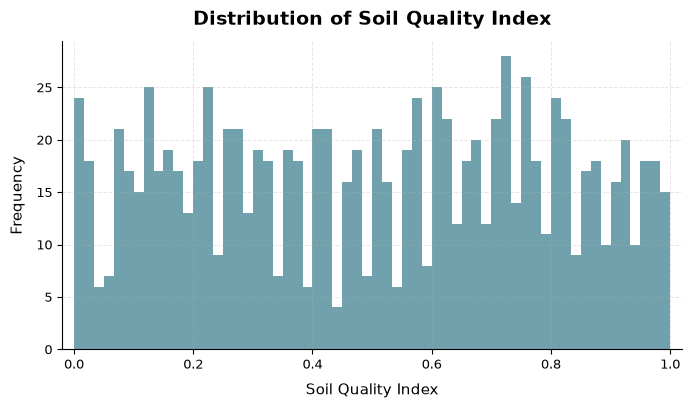

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    X_standardise_df["soil_quality_index"],
    bins = 60,
    alpha=0.7,
    color = "#347989"
)

style_plot(
    ax,
    title="Distribution of Soil Quality Index",
    xlabel="Soil Quality Index",
    ylabel="Frequency",
    grid=True,
)

plt.show()

Furthermore, the standard error for these newly normalised variables is all relatively similar at +-0.28.

In [28]:
X_standardise_df.describe().loc['std']

water_quality_index               0.292836
climate_change_impact_score       0.286481
land_use_change                   0.284973
invasive_species_count            0.289240
conservation_funding              0.289181
eco_tourism_impact                0.289451
forest_cover_change               0.291411
soil_quality_index                0.288788
water_usage                       0.287999
renewable_energy_usage            0.293821
carbon_emission_levels            0.292679
agricultural_intensity            0.287518
habitat_connectivity              0.288884
species_reintroduction_efforts    0.288577
pollinator_diversity              0.286090
Name: std, dtype: float64

### __Conclusion__

In this notebook, we have seen or been introduced to:

- The difference between scaling and standardising the predictor variables in our dataset.
- The different scaling techniques and performed scaling on our data using standardisation and normalisation